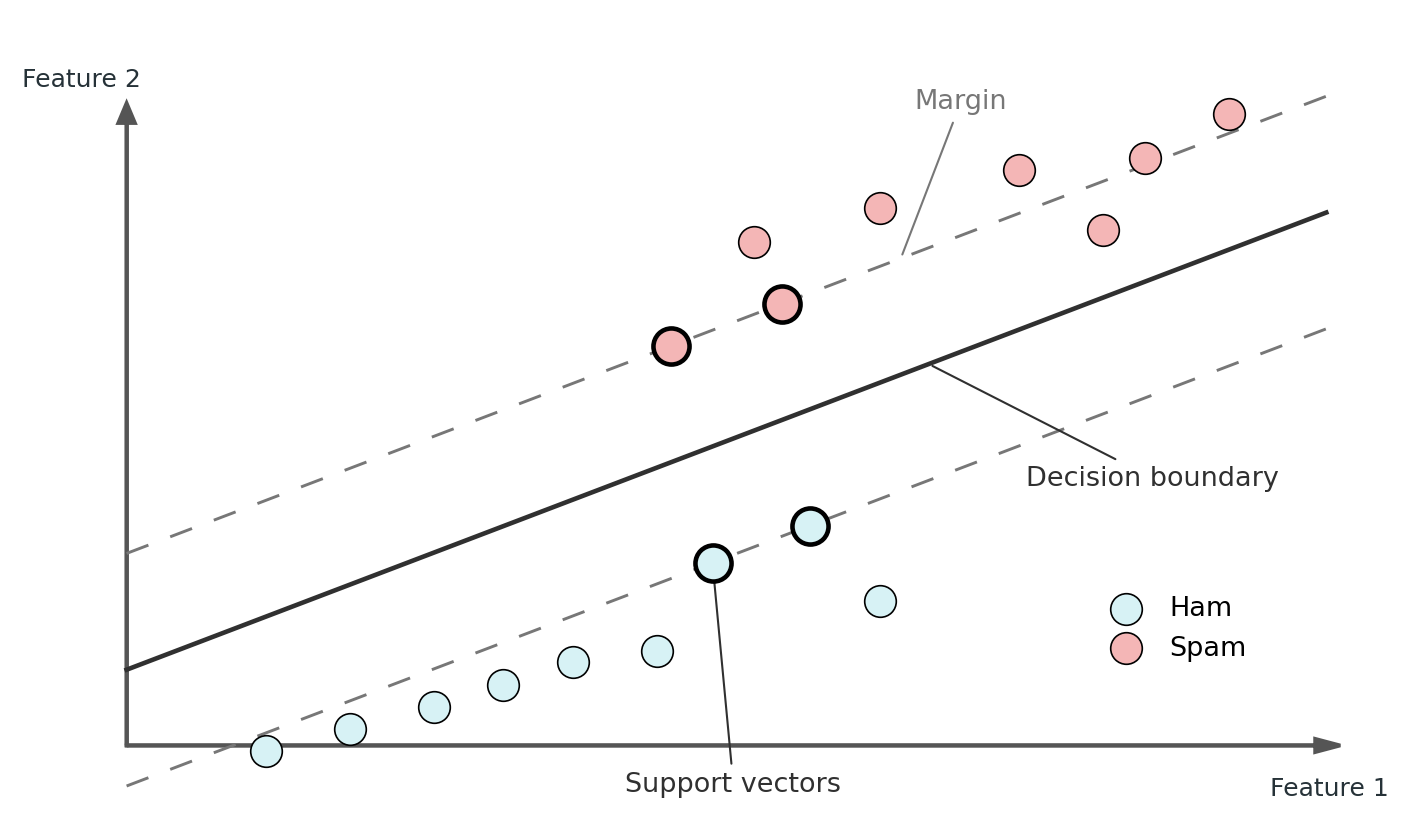

Saved to: D:\Project\Leeds\Msc Project\figure\figure_2_2_svm_margin.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Save path
project_dir = Path(r"D:\Project\Leeds\Msc Project")
figure_dir = project_dir / "figure"
figure_dir.mkdir(parents=True, exist_ok=True)

output_path = figure_dir / "figure_2_2_svm_margin.png"

# Figure setup
plt.figure(figsize=(12, 7), dpi=150)
ax = plt.gca()
ax.set_xlim(0, 10)
ax.set_ylim(0, 7.3)
ax.axis("off")

# Axes with arrows
ax.arrow(0.8, 0.7, 8.7, 0, head_width=0.12, head_length=0.18,
         fc="#555555", ec="#555555", linewidth=1.8, length_includes_head=True)
ax.arrow(0.8, 0.7, 0, 5.8, head_width=0.12, head_length=0.18,
         fc="#555555", ec="#555555", linewidth=1.8, length_includes_head=True)

ax.text(9.0, 0.25, "Feature 1", fontsize=12, color="#263238")
ax.text(0.05, 6.65, "Feature 2", fontsize=12, color="#263238")

# Decision boundary and margins
x = np.linspace(0.8, 9.4, 300)
slope = 0.48
intercept = 1.00
margin_width = 1.05

def boundary_y(values):
    return slope * values + intercept

def upper_margin_y(values):
    return boundary_y(values) + margin_width

def lower_margin_y(values):
    return boundary_y(values) - margin_width

boundary = boundary_y(x)
margin_upper = upper_margin_y(x)
margin_lower = lower_margin_y(x)

ax.plot(x, boundary, color="#303030", linewidth=2.2, zorder=1)
ax.plot(x, margin_upper, color="#777777", linestyle=(0, (8, 8)), linewidth=1.4, zorder=1)
ax.plot(x, margin_lower, color="#777777", linestyle=(0, (8, 8)), linewidth=1.4, zorder=1)

# Sample points
ham = np.array([
    [1.8, 0.65], [2.4, 0.85], [3.0, 1.05], [3.5, 1.25],
    [4.0, 1.45], [4.6, 1.55], [6.2, 2.00]
])

spam = np.array([
    [5.3, 5.25], [6.2, 5.55], [7.2, 5.90], [8.1, 6.00],
    [8.7, 6.40], [7.8, 5.35]
])

# Support vectors are placed exactly on the two margin lines.
support_ham_x = np.array([5.0, 5.7])
support_spam_x = np.array([4.7, 5.5])
support_ham = np.column_stack((support_ham_x, lower_margin_y(support_ham_x)))
support_spam = np.column_stack((support_spam_x, upper_margin_y(support_spam_x)))

# Plot normal points
ax.scatter(ham[:, 0], ham[:, 1], s=230, c="#d7f2f5",
           edgecolors="black", linewidths=0.8, label="Ham", zorder=3)
ax.scatter(spam[:, 0], spam[:, 1], s=230, c="#f4b6b6",
           edgecolors="black", linewidths=0.8, label="Spam", zorder=3)

# Plot support vectors with thicker outlines
ax.scatter(support_ham[:, 0], support_ham[:, 1], s=300, c="#d7f2f5",
           edgecolors="black", linewidths=2.2, zorder=4)
ax.scatter(support_spam[:, 0], support_spam[:, 1], s=300, c="#f4b6b6",
           edgecolors="black", linewidths=2.2, zorder=4)

# Annotations
ax.annotate("Margin",
            xy=(6.35, upper_margin_y(6.35)), xytext=(6.45, 6.45),
            fontsize=13, color="#777777",
            arrowprops=dict(arrowstyle="-", color="#777777", linewidth=1.0))

ax.annotate("Decision boundary",
            xy=(6.55, boundary_y(6.55)), xytext=(7.25, 3.05),
            fontsize=13, color="#303030",
            arrowprops=dict(arrowstyle="-", color="#303030", linewidth=1.0))

# Support vectors are the outlined samples on the margin lines.
ax.annotate("Support vectors",
            xy=(support_ham[0, 0], support_ham[0, 1]), xytext=(5.15, 0.28),
            fontsize=13, color="#303030", ha="center",
            arrowprops=dict(arrowstyle="-", color="#303030", linewidth=1.0))

# Legend
legend = ax.legend(loc="lower right", bbox_to_anchor=(0.90, 0.17),
                   frameon=False, fontsize=13, handletextpad=0.6)
for handle in legend.legend_handles:
    handle.set_sizes([230])

# Save and display
plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved to: {output_path}")